In [1]:
import os
import sys
import time
import dask
import zarr
import numpy as np
import xarray as xr
import pandas as pd
from glob import glob
from scipy.stats import norm
from scipy.interpolate import interp1d
from tqdm import tqdm

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
# ================================================ #
# -------------------- config -------------------- #

lat_i = 0 #int(args['lat_i'])
VAR = VAR_CESM = 'PRECT'
VAR_ERA5 = 'total_precipitation'
unit_CESM = 60*60*24 * 1000 # m/s to mm/day
unit_ERA5 = 1000  # m/day to mm/day
verif_years = np.arange(2010, 2020)


WINDOW = 0
MIN_SAMPLES = 20
EPS = 1e-6
N_QUANTILES = 200   # number of quantile levels for the mapping table
# Day-of-year index for each lead time
N_DOY = 365
DOY_WINDOW = 15  # ±15 days around each doy for pooling

QM_DIR = f'/glade/derecho/scratch/ksha/EPRI_data/QM/{VAR_CESM}'
SAVE_QM_CESM   = f'{QM_DIR}/qm_cesm_lat_ind_{lat_i}.zarr'
SAVE_QM_ERA5   = f'{QM_DIR}/qm_era5_lat_ind_{lat_i}.zarr'

SAVE_DIR = f'/glade/derecho/scratch/ksha/EPRI_data/QM_PRED/{VAR_CESM}'
SAVE_MAPPED_INPUT  = f'{SAVE_DIR}/pred_input_lat_ind_{lat_i}.zarr'
SAVE_MAPPED_TARGET = f'{SAVE_DIR}/pred_target_lat_ind_{lat_i}.zarr'

# ================================================ #
# --------------------- data --------------------- #
list_input = []
for year in verif_years:
    fn_CESM = f'/glade/derecho/scratch/ksha/EPRI_data/CESM2_SMYLE/SMYLE_{year}-11-01_daily_ensemble.zarr'
    ds_CESM = xr.open_zarr(fn_CESM)[[VAR_CESM,]].sel(time=slice(f"{year+1}-01-01", f"{year+10}-12-31"))
    ds_CESM = ds_CESM.rename({'time': 'lead_time'})
    ds_CESM['lead_time'] = np.arange(3650) # 10 non-leap year, 365 day on each 
    list_input.append(ds_CESM.isel(lat=lat_i))

ds_input = xr.concat(list_input, dim='init_time')
ds_input = ds_input.assign_coords({'init_time': verif_years+1})

list_target = []
for year in range(verif_years[0], 2026):
    fn_ERA5 = f'/glade/derecho/scratch/ksha/EPRI_data/ERA5_grid/ERA5_{year}.zarr'
    ds_ERA5 = xr.open_zarr(fn_ERA5)[[VAR_ERA5,]].rename({VAR_ERA5: VAR_CESM})    
    list_target.append(ds_ERA5.isel(lat=lat_i))

ds_target = xr.concat(list_target, dim='time')

ds_input[VAR_CESM] = ds_input[VAR_CESM] * unit_CESM
ds_target[VAR_CESM] = ds_target[VAR_CESM] * unit_ERA5

ds_qm_cesm = xr.open_zarr(SAVE_QM_CESM)
ds_qm_era5 = xr.open_zarr(SAVE_QM_ERA5)


In [4]:
# ════════════════════════════════════════════════════════════════════════
# Noleap calendar mapping
# ════════════════════════════════════════════════════════════════════════

def build_date_indices(init_years, n_lead, target_times):
    time_to_idx = {pd.Timestamp(t): i for i, t in enumerate(target_times)}
    indices = np.full((len(init_years), n_lead), -1, dtype=np.int32)
    for i, year in enumerate(init_years):
        year = int(year)
        noleap_dates = []
        for y in range(year, year + 10):
            days = pd.date_range(f'{y}-01-01', f'{y}-12-31', freq='D')
            days = days[~((days.month == 2) & (days.day == 29))]
            noleap_dates.extend(days.tolist())
        for L in range(min(n_lead, len(noleap_dates))):
            d = noleap_dates[L]
            if d in time_to_idx:
                indices[i, L] = time_to_idx[d]
    return indices

init_years = ds_input.init_time.values
n_init = len(init_years)
n_lead = ds_input.sizes['lead_time']
n_lon  = ds_input.sizes['lon']
n_member = ds_input.sizes['member']

target_times_pd = pd.DatetimeIndex(ds_target.time.values)
date_idx = build_date_indices(init_years, n_lead, target_times_pd)

In [8]:
def extrapolate_upper_tail(q_values):
    """
    Estimate the quantile at level 1.0 by linearly extrapolating
    from the two highest quantile levels (0.9925 and 0.9975).
    Appends the extrapolated value and returns extended arrays.
    """
    v1 = q_values[-2]  # quantile at 0.9925
    v2 = q_values[-1]  # quantile at 0.9975
    l1 = q_levels[-2]
    l2 = q_levels[-1]

    # Linear extrapolation to level 1.0
    slope = (v2 - v1) / (l2 - l1)
    v_max = v2 + slope * (1.0 - l2)
    v_max = max(v_max, v2)  # ensure monotonicity

    q_ext = np.append(q_values, np.float32(v_max))
    l_ext = np.append(q_levels, 1.0)
    return q_ext, l_ext

def precip_to_gaussian(values, q_values, wet_frac):
    """
    Map precipitation values to Gaussian space.

    Strategy for zero-inflated precipitation:
      1. Compute empirical CDF rank for each value
      2. For zeros: assign a random uniform rank in [0, 1-wet_frac]
         (jittered to avoid a point mass in Gaussian space)
      3. For positives: interpolate within the empirical quantile table
         (with upper tail extrapolated to quantile level 1.0)
      4. Map uniform ranks to Gaussian via norm.ppf
    """
    n = len(values)
    gaussian = np.full(n, np.nan, dtype=np.float32)

    if np.all(np.isnan(q_values)):
        return gaussian

    valid = ~np.isnan(values)
    vals = np.maximum(values[valid], 0.0)

    # Extend quantile table with extrapolated upper tail
    q_ext, l_ext = extrapolate_upper_tail(q_values)

    # Build interpolator: precipitation → quantile level (uniform CDF)
    q_unique, idx_unique = np.unique(q_ext, return_index=True)
    ql_unique = l_ext[idx_unique]

    if len(q_unique) < 2:
        gaussian[valid] = 0.0
        return gaussian

    interp_func = interp1d(
        q_unique, ql_unique,
        kind='linear',
        bounds_error=False,
        fill_value=(ql_unique[0], ql_unique[-1]),
    )

    # Map to uniform CDF ranks
    u = interp_func(vals)

    # Handle zeros: jitter within [eps, dry_frac] to spread the point mass
    dry_frac = 1.0 - wet_frac
    if dry_frac > 0:
        is_zero = vals <= 0.0
        rng = np.random.default_rng(42)
        u[is_zero] = rng.uniform(EPS, max(dry_frac, 2 * EPS), size=is_zero.sum())

    # Clip to avoid infinite Gaussian values
    u = np.clip(u, 1e-6, 1.0 - 1e-6)

    # Uniform → Gaussian
    gaussian[valid] = norm.ppf(u).astype(np.float32)

    return gaussian


def gaussian_to_precip(gaussian_values, q_values, wet_frac):
    """
    Inverse transform: Gaussian space → precipitation.
    Uses extrapolated upper tail for values beyond the training range.
    """
    shape = gaussian_values.shape
    g_flat = gaussian_values.ravel()
    precip = np.full_like(g_flat, np.nan, dtype=np.float32)

    if np.all(np.isnan(q_values)):
        return precip.reshape(shape)

    valid = ~np.isnan(g_flat)

    # Gaussian → uniform
    u = norm.cdf(g_flat[valid])

    # Censor: if u <= dry_frac, output zero
    dry_frac = 1.0 - wet_frac
    result = np.zeros_like(u)

    wet_mask = u > dry_frac
    if wet_mask.any():
        # Extend quantile table with extrapolated upper tail
        q_ext, l_ext = extrapolate_upper_tail(q_values)

        q_unique, idx_unique = np.unique(q_ext, return_index=True)
        ql_unique = l_ext[idx_unique]

        if len(q_unique) >= 2:
            inv_func = interp1d(
                ql_unique, q_unique,
                kind='linear',
                bounds_error=False,
                fill_value=(q_unique[0], q_unique[-1]),
            )
            result[wet_mask] = np.maximum(inv_func(u[wet_mask]), 0.0)

    precip[valid] = result.astype(np.float32)
    return precip.reshape(shape)

In [10]:
# ════════════════════════════════════════════════════════════════════════
# Load quantile tables (fitted on training period)
# ════════════════════════════════════════════════════════════════════════

cesm_qtable  = ds_qm_cesm['quantile_values'].values   # (365, n_lon, N_QUANTILES)
cesm_wetfrac = ds_qm_cesm['wet_fraction'].values       # (365, n_lon)
era5_qtable  = ds_qm_era5['quantile_values'].values
era5_wetfrac = ds_qm_era5['wet_fraction'].values
q_levels     = ds_qm_cesm['quantile'].values

doy = np.arange(n_lead) % N_DOY

# ════════════════════════════════════════════════════════════════════════
# Load raw data into memory
# ════════════════════════════════════════════════════════════════════════

print("Loading data into memory …")
input_data  = ds_input[VAR_CESM].values.astype(np.float32)   # (init, member, lead, lon)
target_data = ds_target[VAR_CESM].values.astype(np.float32)  # (time, lon)

input_data  = np.maximum(input_data, 0.0)
target_data = np.maximum(target_data, 0.0)

In [9]:
# ════════════════════════════════════════════════════════════════════════
# Transform CESM verification data → Gaussian using training quantiles
# ════════════════════════════════════════════════════════════════════════

print("Transforming CESM verification data to Gaussian space …")
input_gaussian = np.full_like(input_data, np.nan)

for lt in tqdm(range(n_lead), desc='CESM → Gaussian'):
    d = doy[lt]
    for lo in range(n_lon):
        qt = cesm_qtable[d, lo, :]
        wf = cesm_wetfrac[d, lo]
        if np.isnan(wf):
            continue
        vals = input_data[:, :, lt, lo].ravel()
        mapped = precip_to_gaussian(vals, qt, wf)
        input_gaussian[:, :, lt, lo] = mapped.reshape(n_init, n_member)

# ════════════════════════════════════════════════════════════════════════
# Transform ERA5 verification data → Gaussian (matched to init/lead)
# ════════════════════════════════════════════════════════════════════════

print("Transforming ERA5 verification data to Gaussian space …")
target_gaussian_matched = np.full(
    (n_init, n_lead, n_lon), np.nan, dtype=np.float32
)

for lt in tqdm(range(n_lead), desc='ERA5 → Gaussian (matched)'):
    d = doy[lt]
    time_indices = date_idx[:, lt]
    valid_mask = time_indices >= 0
    if not valid_mask.any():
        continue
    valid_inits = np.where(valid_mask)[0]
    valid_times = time_indices[valid_mask]

    for lo in range(n_lon):
        qt = era5_qtable[d, lo, :]
        wf = era5_wetfrac[d, lo]
        if np.isnan(wf):
            continue
        vals = target_data[valid_times, lo]
        mapped = precip_to_gaussian(vals, qt, wf)
        target_gaussian_matched[valid_inits, lt, lo] = mapped

# ════════════════════════════════════════════════════════════════════════
# Save transformed verification datasets
# ════════════════════════════════════════════════════════════════════════

print("Saving Gaussian-transformed CESM verification …")
ds_input_gauss = ds_input.copy(deep=False)
ds_input_gauss[VAR_CESM] = xr.DataArray(
    input_gaussian,
    dims=ds_input[VAR_CESM].dims,
    coords=ds_input[VAR_CESM].coords,
)
ds_input_gauss.attrs['transform'] = 'NQT applied using training-period quantile tables'
ds_input_gauss.to_zarr(SAVE_MAPPED_INPUT, mode='w')

print("Saving Gaussian-transformed ERA5 verification …")
ds_target_gauss = xr.Dataset(
    {
        VAR_CESM: (['init_time', 'lead_time', 'lon'], target_gaussian_matched),
    },
    coords={
        'init_time':  ds_input.init_time.values,
        'lead_time':  ds_input.lead_time.values,
        'lon':        ds_input.lon.values,
        'lat':        ds_input.lat.values,
    },
)
ds_target_gauss.attrs['transform'] = 'NQT applied using training-period quantile tables (matched to init/lead)'
ds_target_gauss.to_zarr(SAVE_MAPPED_TARGET, mode='w')

print("\nDone. Verification datasets ready for Gaussian EMOS evaluation.")

Transforming CESM verification data to Gaussian space …


CESM → Gaussian: 100%|██████████| 3650/3650 [11:40<00:00,  5.21it/s]


Transforming ERA5 verification data to Gaussian space …


ERA5 → Gaussian (matched): 100%|██████████| 3650/3650 [10:57<00:00,  5.55it/s]


Saving Gaussian-transformed CESM verification …
Saving Gaussian-transformed ERA5 verification …

Done. Verification datasets ready for Gaussian EMOS evaluation.


In [6]:
ds_qm_cesm

<xarray.Dataset> Size: 85MB
Dimensions:          (doy: 365, lon: 288, quantile: 200)
Coordinates:
  * doy              (doy) int64 3kB 0 1 2 3 4 5 6 ... 359 360 361 362 363 364
    lat              float64 8B ...
  * lon              (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
  * quantile         (quantile) float64 2kB 0.0025 0.0075 ... 0.9925 0.9975
Data variables:
    quantile_values  (doy, lon, quantile) float32 84MB dask.array<chunksize=(92, 72, 50), meta=np.ndarray>
    wet_fraction     (doy, lon) float32 420kB dask.array<chunksize=(183, 288), meta=np.ndarray>
Attributes:
    description:  Empirical quantile table for CESM2-SMYLE PRECT (lat_i=0). 2...

In [6]:
# Quantile levels (avoid exact 0 and 1 to keep Gaussian values finite)
q_levels = np.linspace(0.5 / N_QUANTILES, 1.0 - 0.5 / N_QUANTILES, N_QUANTILES)
# q_levels = [0.0025, ..., 0.9925, 0.9975]

# ════════════════════════════════════════════════════════════════════════
# Step 1: Build quantile tables per (day-of-year, lon)
# ════════════════════════════════════════════════════════════════════════

print("Loading data into memory …")
input_data  = ds_input[VAR_CESM].values.astype(np.float32)   # (init, member, lead, lon)
target_data = ds_target[VAR_CESM].values.astype(np.float32)  # (time, lon)

# Censor negatives
input_data  = np.maximum(input_data, 0.0)
target_data = np.maximum(target_data, 0.0)


doy = np.arange(n_lead) % 365

# Precompute which lead indices belong to each doy (with window)
doy_to_leads = {}
for d in range(N_DOY):
    mask = np.zeros(n_lead, dtype=bool)
    for offset in range(-DOY_WINDOW, DOY_WINDOW + 1):
        mask[doy == (d + offset) % 365] = True
    doy_to_leads[d] = np.where(mask)[0]

# ── CESM quantile tables: (365, n_lon) ──
print("Building CESM quantile tables per (doy, lon) …")
cesm_qtable  = np.full((N_DOY, n_lon, N_QUANTILES), np.nan, dtype=np.float32)
cesm_wetfrac = np.full((N_DOY, n_lon), np.nan, dtype=np.float32)

for d in tqdm(range(N_DOY), desc='CESM qtable'):
    lt_indices = doy_to_leads[d]
    for lo in range(n_lon):
        samples = input_data[:, :, lt_indices, lo].ravel()
        cesm_qtable[d, lo, :], cesm_wetfrac[d, lo] = build_quantile_table(samples)

# ── ERA5 quantile tables: (365, n_lon) ──
print("Building ERA5 quantile tables per (doy, lon) …")
era5_qtable  = np.full((N_DOY, n_lon, N_QUANTILES), np.nan, dtype=np.float32)
era5_wetfrac = np.full((N_DOY, n_lon), np.nan, dtype=np.float32)

for d in tqdm(range(N_DOY), desc='ERA5 qtable'):
    lt_indices = doy_to_leads[d]

    # Gather all matched ERA5 time indices for these leads
    all_time_idx = []
    for lt in lt_indices:
        ti = date_idx[:, lt]
        all_time_idx.append(ti[ti >= 0])

    if len(all_time_idx) == 0:
        continue
    valid_times = np.concatenate(all_time_idx)

    if len(valid_times) == 0:
        continue

    for lo in range(n_lon):
        samples = target_data[valid_times, lo]
        era5_qtable[d, lo, :], era5_wetfrac[d, lo] = build_quantile_table(samples)

# ════════════════════════════════════════════════════════════════════════
# Step 2: Apply quantile mapping → Gaussian space
# ════════════════════════════════════════════════════════════════════════

# ── Transform CESM ──
print("Transforming CESM to Gaussian space …")
input_gaussian = np.full_like(input_data, np.nan)  # (init, member, lead, lon)

for lt in tqdm(range(n_lead), desc='CESM → Gaussian'):
    d = doy[lt]
    for lo in range(n_lon):
        qt = cesm_qtable[d, lo, :]
        wf = cesm_wetfrac[d, lo]
        if np.isnan(wf):
            continue
        vals = input_data[:, :, lt, lo].ravel()
        mapped = precip_to_gaussian(vals, qt, wf)
        input_gaussian[:, :, lt, lo] = mapped.reshape(n_init, n_member)

# ── Transform ERA5 ──
print("Transforming ERA5 to Gaussian space …")
target_gaussian = np.full_like(target_data, np.nan)  # (time, lon)

for lt in tqdm(range(n_lead), desc='ERA5 → Gaussian'):
    d = doy[lt]
    time_indices = date_idx[:, lt]
    valid_mask = time_indices >= 0

    if not valid_mask.any():
        continue

    valid_times = time_indices[valid_mask]

    for lo in range(n_lon):
        qt = era5_qtable[d, lo, :]
        wf = era5_wetfrac[d, lo]
        if np.isnan(wf):
            continue
        vals = target_data[valid_times, lo]
        mapped = precip_to_gaussian(vals, qt, wf)
        target_gaussian[valid_times, lo] = mapped

Loading data into memory …
Building CESM quantile tables per (doy, lon) …


CESM qtable: 100%|██████████| 365/365 [31:16<00:00,  5.14s/it]


Building ERA5 quantile tables per (doy, lon) …


ERA5 qtable: 100%|██████████| 365/365 [01:38<00:00,  3.69it/s]


Transforming CESM to Gaussian space …


CESM → Gaussian: 100%|██████████| 3650/3650 [07:32<00:00,  8.07it/s]


Transforming ERA5 to Gaussian space …


ERA5 → Gaussian: 100%|██████████| 3650/3650 [04:57<00:00, 12.26it/s]


In [43]:
# plt.plot(cesm_qtable[0, 0, :])
# plt.plot(cesm_qtable[364, 0, :])

In [8]:
# ── CESM quantile table ──
ds_qm_cesm = xr.Dataset(
    {
        'quantile_values': (['doy', 'lon', 'quantile'], cesm_qtable),
        'wet_fraction':    (['doy', 'lon'], cesm_wetfrac),
    },
    coords={
        'doy':       np.arange(N_DOY),
        'lon':       ds_input.lon.values,
        'lat':       ds_input.lat.values,
        'quantile':  q_levels,
    },
)
ds_qm_cesm.attrs['description'] = (
    f'Empirical quantile table for CESM2-SMYLE {VAR_CESM} (lat_i={lat_i}). '
    f'{N_QUANTILES} quantile levels, doy_window={DOY_WINDOW}.'
)
ds_qm_cesm.to_zarr(SAVE_QM_CESM, mode='w')

# ── ERA5 quantile table ──
ds_qm_era5 = xr.Dataset(
    {
        'quantile_values': (['doy', 'lon', 'quantile'], era5_qtable),
        'wet_fraction':    (['doy', 'lon'], era5_wetfrac),
    },
    coords={
        'doy':       np.arange(N_DOY),
        'lon':       ds_input.lon.values,
        'lat':       ds_input.lat.values,
        'quantile':  q_levels,
    },
)
ds_qm_era5.attrs['description'] = (
    f'Empirical quantile table for ERA5 {VAR_CESM} (lat_i={lat_i}). '
    f'{N_QUANTILES} quantile levels, doy_window={DOY_WINDOW}.'
)
ds_qm_era5.to_zarr(SAVE_QM_ERA5, mode='w')

In [9]:
  # Y = np.full_like(X_mean, np.nan)
  # for i in range(n_init):
  #     mask = date_idx[i] >= 0
  #     Y[i, mask, :] = target_gaussian[date_idx[i, mask], :]

In [10]:
# =============================================== #
# --------------- Transformed CESM -------------- #
print("Saving Gaussian-transformed CESM …")
ds_input_gauss = ds_input.copy(deep=False)
ds_input_gauss[VAR_CESM] = xr.DataArray(
    input_gaussian,
    dims=ds_input[VAR_CESM].dims,
    coords=ds_input[VAR_CESM].coords,
)
ds_input_gauss.attrs['transform'] = 'NQT: Normal Quantile Transform'
ds_input_gauss.to_zarr(SAVE_MAPPED_INPUT, mode='w')

# =============================================== #
# -------------- Transformed ERA5  -------------- #
print("Saving Gaussian-transformed ERA5 …")
ds_target_gauss = ds_target.copy(deep=False)
ds_target_gauss[VAR_CESM] = xr.DataArray(
    target_gaussian,
    dims=ds_target[VAR_CESM].dims,
    coords=ds_target[VAR_CESM].coords,
)
ds_target_gauss.attrs['transform'] = 'NQT: Normal Quantile Transform'
ds_target_gauss.to_zarr(SAVE_MAPPED_TARGET, mode='w')
 
print("\nAll done. Next steps:")
print("  1. Run Gaussian EMOS on the transformed datasets")
print("  2. Use gaussian_to_precip() with ERA5 quantile tables to inverse-transform predictions")

Saving Gaussian-transformed CESM …
Saving Gaussian-transformed ERA5 …

All done. Next steps:
  1. Run Gaussian EMOS on the transformed datasets
  2. Use gaussian_to_precip() with ERA5 quantile tables to inverse-transform predictions


In [11]:
after post-processing `ds_input_gauss` based on `ds_target_gauss`, how to convert it back to precipitation?

<xarray.Dataset> Size: 29MB
Dimensions:  (time: 24837, lon: 288)
Coordinates:
    lat      float64 8B -90.0
    level    int64 8B 500
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * time     (time) datetime64[ns] 199kB 1958-01-01 1958-01-02 ... 2025-12-31
Data variables:
    PRECT    (time, lon) float32 29MB nan nan nan nan nan ... nan nan nan nan
Attributes:
    regrid_method:  bilinear
    transform:      NQT: Normal Quantile Transform

In [14]:
tp = ds_input_gauss['PRECT'].isel(init_time=30, member=0).values

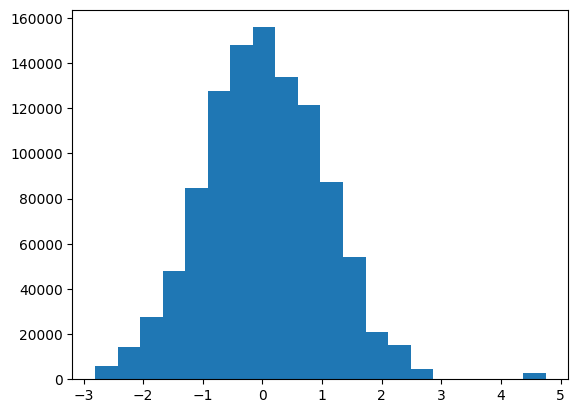

In [17]:
plt.hist(tp.ravel(), bins=20);

In [38]:
`ds_target_gauss` is nan for the first year (1958), why and how to fix it?

<xarray.Dataset> Size: 29MB
Dimensions:  (time: 24837, lon: 288)
Coordinates:
    lat      float64 8B -90.0
    level    int64 8B 500
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * time     (time) datetime64[ns] 199kB 1958-01-01 1958-01-02 ... 2025-12-31
Data variables:
    PRECT    (time, lon) float32 29MB nan nan nan nan nan ... nan nan nan nan
Attributes:
    regrid_method:  bilinear
    transform:      NQT: Normal Quantile Transform

In [40]:
TP = ds_target_gauss['PRECT'].isel(time=slice(365, None)).values

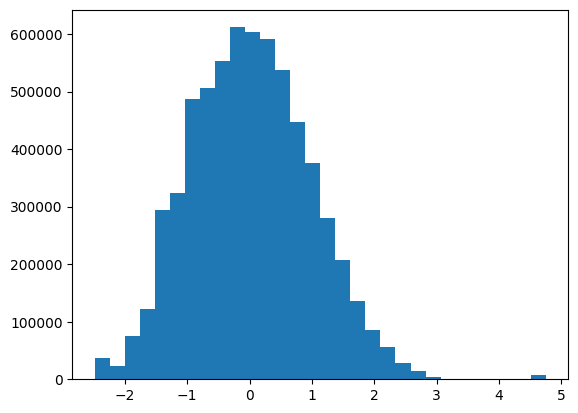

In [42]:
plt.hist(TP.ravel(), bins=30);